In [1]:
%matplotlib inline

In [2]:
import torch
from torch.distributions import multinomial
from d2l import torch as d2l

In [3]:
fair_probs = torch.ones([6])/6

In [4]:
fair_probs

tensor([0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667])

In [5]:
torch.ones([6])

tensor([1., 1., 1., 1., 1., 1.])

In [6]:
torch.ones(6)

tensor([1., 1., 1., 1., 1., 1.])

In [7]:
torch.ones((6))

tensor([1., 1., 1., 1., 1., 1.])

In [8]:
torch.ones([6,4])

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [9]:
torch.ones(6,2)

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [10]:
torch.ones((6,2))

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [21]:
counts = multinomial.Multinomial(10,fair_probs).sample((2,))  # 做二次抛10个筛子的实验

In [22]:
counts / 10

tensor([[0.2000, 0.3000, 0.1000, 0.1000, 0.2000, 0.1000],
        [0.3000, 0.2000, 0.1000, 0.0000, 0.2000, 0.2000]])

In [ ]:
counts = multinomial.Multinomial(10,fair_probs).sample((500,))

In [30]:
counts

tensor([[4., 1., 0., 2., 0., 3.],
        [3., 3., 2., 2., 0., 0.],
        [1., 2., 1., 2., 2., 2.],
        ...,
        [0., 2., 2., 2., 1., 3.],
        [2., 2., 0., 1., 3., 2.],
        [2., 1., 3., 1., 2., 1.]])

In [33]:
cum_counts = counts.cumsum(dim=0)  # 第0维做累加和 行相加 下加

In [34]:
cum_counts

tensor([[  4.,   1.,   0.,   2.,   0.,   3.],
        [  7.,   4.,   2.,   4.,   0.,   3.],
        [  8.,   6.,   3.,   6.,   2.,   5.],
        ...,
        [838., 838., 823., 827., 871., 783.],
        [840., 840., 823., 828., 874., 785.],
        [842., 841., 826., 829., 876., 786.]])

In [35]:
estimates = cum_counts / cum_counts.sum(dim=1,keepdims=True)

In [36]:
estimates

tensor([[0.4000, 0.1000, 0.0000, 0.2000, 0.0000, 0.3000],
        [0.3500, 0.2000, 0.1000, 0.2000, 0.0000, 0.1500],
        [0.2667, 0.2000, 0.1000, 0.2000, 0.0667, 0.1667],
        ...,
        [0.1683, 0.1683, 0.1653, 0.1661, 0.1749, 0.1572],
        [0.1683, 0.1683, 0.1649, 0.1659, 0.1752, 0.1573],
        [0.1684, 0.1682, 0.1652, 0.1658, 0.1752, 0.1572]])

In [37]:
d2l.set_figsize((6,4.5))

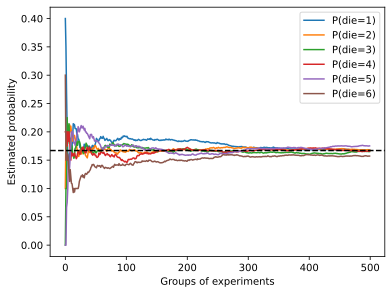

In [42]:
for i in range(6):
    d2l.plt.plot(estimates[:,i].numpy(),label=("P(die=" + str(i+1) + ")"))
d2l.plt.axhline(y=0.167,color="black",linestyle="dashed")
d2l.plt.gca().set_xlabel("Groups of experiments")
d2l.plt.gca().set_ylabel("Estimated probability")
d2l.plt.legend()

In [43]:
# 贝叶斯定理 根据证据去修改概论 违反直觉